# Проект по теме "Машинное обучение в бизнесе": 
# Выбор локации для скважины

Нашему отделу аналитики в добывающей компании «ГлавРосГосНефть» нужно решить, где бурить новую скважину. 

Шаги для выбора локации следующие:
- В избранном регионе собираем характеристики для скважин: качество нефти и объём её запасов;
- Строим модель для предсказания объёма запасов в новых скважинах;
- Выбираем скважины с самыми высокими оценками значений;
- Определяем регион с максимальной суммарной прибылью отобранных скважин.

Нам предоставлены пробы нефти в трёх регионах. Характеристики для каждой скважины в регионе уже известны. Построим модель для определения региона, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой Bootstrap.

Добавим необходимые библиотеки:

In [1]:
!pip install phik

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from phik.report import plot_correlation_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import norm

### Константы

In [3]:
RANDOM_STATE = 42
BUDGET = 10_000_000_000  # в рублях
BARREL_INCOME = 450_000  # доход с 1 тыс. баррелей
NUM_WELLS = 500
SELECTED_WELLS = 200
BOOTSTRAP_ITERATIONS = 1000
LOSS_PROB_THRESHOLD = 0.025

# Загрузка, знакомство и предобработка данных

## Загрузка данных

In [4]:
try:
    df_geo_data_0 = pd.read_csv('/datasets/geo_data_0.csv', sep=',')
    df_geo_data_1 = pd.read_csv('/datasets/geo_data_1.csv', sep=',')
    df_geo_data_2 = pd.read_csv('/datasets/geo_data_2.csv', sep=',')
except FileNotFoundError:
    df_geo_data_0 = pd.read_csv('geo_data_0.csv', sep=',')
    df_geo_data_1 = pd.read_csv('geo_data_1.csv', sep=',')
    df_geo_data_2 = pd.read_csv('geo_data_2.csv', sep=',')

## Знакомство с данными

 Добавим функцию для знакомства с данными:

In [5]:
def get_dataset_info(df, name="Dataset", sample_rows=5):
    """
    Параметры:
    - df (pd.DataFrame): Датасет для анализа.
    - name (str): Название датасета (для заголовка).
    - sample_rows (int): Количество строк для вывода (head).
    Возвращает:
    - dict: Словарь с основной информацией о датасете.
    """
    info = {
        "name": name,
        "head": df.head(sample_rows),
        "shape": df.shape,
    }

    # Вывод информации в консоль
    print("\nОбщая информация:")
    display(df.info())
    
    
    print("\nРазмер датасета (строки, столбцы):")
    display(f"{info['shape']} (rows, cols)")


    print("\nПервые строки данных:")
    display(info["head"])

In [6]:
get_dataset_info(df_geo_data_0)


Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


None


Размер датасета (строки, столбцы):


'(100000, 5) (rows, cols)'


Первые строки данных:


,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


In [7]:
get_dataset_info(df_geo_data_1)


Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


None


Размер датасета (строки, столбцы):


'(100000, 5) (rows, cols)'


Первые строки данных:


,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


In [8]:
get_dataset_info(df_geo_data_2)


Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


None


Размер датасета (строки, столбцы):


'(100000, 5) (rows, cols)'


Первые строки данных:


,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


### Итоги
Видим 3 идентичных датасета (по признакам), в которых:
- id — уникальный идентификатор скважины;
- f0, f1, f2 — три признака точек (неважно, что они означают, но сами признаки значимы);
- product — объём запасов в скважине (тыс. баррелей).

Пока очевидных проблем в данных не замечено (названия колонок корректные, типы данных - тоже), перейдём к предобработке.

## Предобработка данных

### Проверка на явные дубликаты и пропуски
Проведём проверку на явные дубликаты и воспользуемся функцией для подсчёта количества дубликатов и пропусков:

In [9]:
def check_duplicates_and_missing(df: pd.DataFrame):
    duplicate_count = df.duplicated().sum()
    print(f"Количество дубликатов: {duplicate_count}")
    
    missing_values = df.isna().sum()
    print(f"Количество пропусков: {missing_values.sum()}")
   

    if duplicate_count == 0 and missing_values.sum() == 0:
        print("\nДубликаты и пропуски отсутствуют.")

Проводить проверку будем без учёта столбца `id`:

In [10]:
print('Проверка первого региона: \n')
check_duplicates_and_missing(df_geo_data_0.drop(columns=['id']))
print('Проверка второго региона: \n')
check_duplicates_and_missing(df_geo_data_1.drop(columns=['id']))
print('Проверка третьего региона: \n')
check_duplicates_and_missing(df_geo_data_2.drop(columns=['id']))

Проверка первого региона: 

Количество дубликатов: 0
Количество пропусков: 0

Дубликаты и пропуски отсутствуют.
Проверка второго региона: 

Количество дубликатов: 0
Количество пропусков: 0

Дубликаты и пропуски отсутствуют.
Проверка третьего региона: 

Количество дубликатов: 0
Количество пропусков: 0

Дубликаты и пропуски отсутствуют.


### Итоги
Дубликатов и пропусков в датасетах нет.

# Исследовательский анализ данных
Проведём исследовательский анализ данных, посмотрим на распределение фичей и целевой переменной, проверим наличие выбросов в данных:

Используем функцию для статистического анализа данных:

In [11]:
def stat_analytics(df):
    df_desc = df.drop(columns=['id'])
    display(df_desc.describe())
    print('\nВизуализация распределения количественных признаков')
    numeric_cols = df.select_dtypes(include=['number']).columns
    for col in numeric_cols:
            plt.figure(figsize=(10, 4))
    
            plt.subplot(1, 2, 1)
            sns.histplot(df[col], kde=True, bins=30)
            plt.title(f'Распределение {col}')
    
            plt.subplot(1, 2, 2)
            sns.boxplot(x=df[col])
            plt.title(f'Boxplot {col}')
    
            plt.tight_layout()
            plt.show()

Проверим 1-й регион:

In [12]:
df_geo_data_0.head()

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347



Визуализация распределения количественных признаков


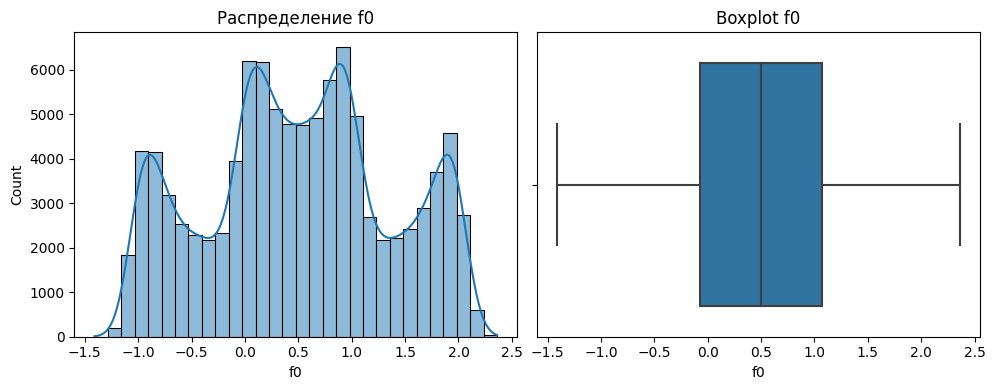

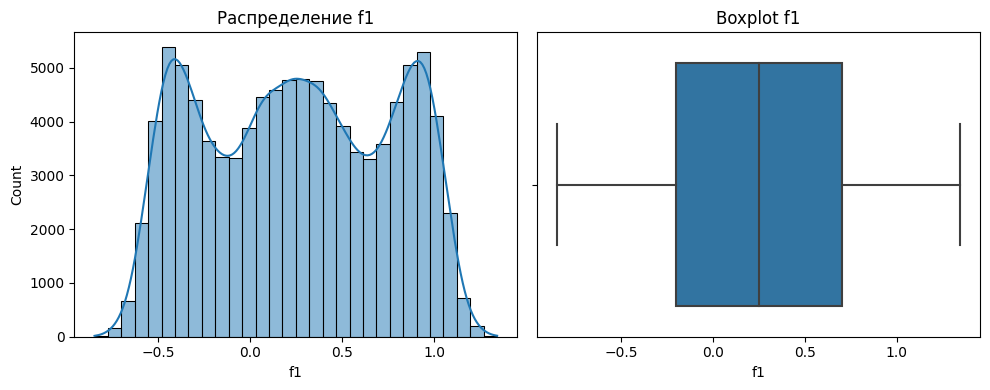

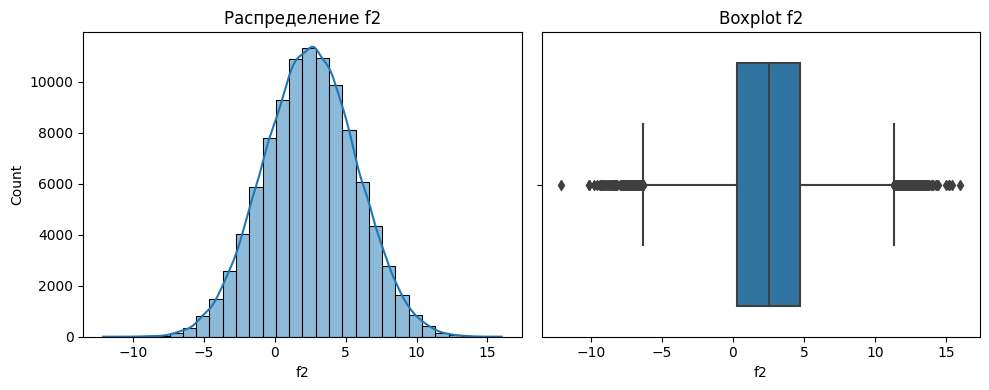

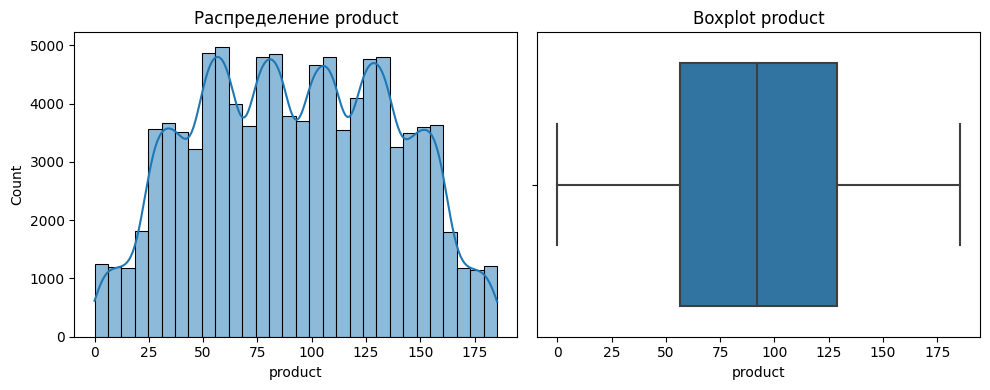

In [13]:
stat_analytics(df_geo_data_0)

### Итоги
Статистический анализ первого региона показал, что:
- product (целевая переменная) имеет мультимодальное распределение: видны несколько "уровней" (пиков) в районе 25, 50, 75, 100, 125 и 150 тыс. баррелей.
- f1 и f0 имеют многомодальное, почти симметричное распределение, без выраженных выбросов.
- f2 имеет почти нормальное распределение с небольшим правосторонним смещением и множеством выбросов. Это может говорить о наличии редких экстремальных значений, в данном случае избавляться от них может быть опасно, так как это сильно может повлиять на работу модели.

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408



Визуализация распределения количественных признаков


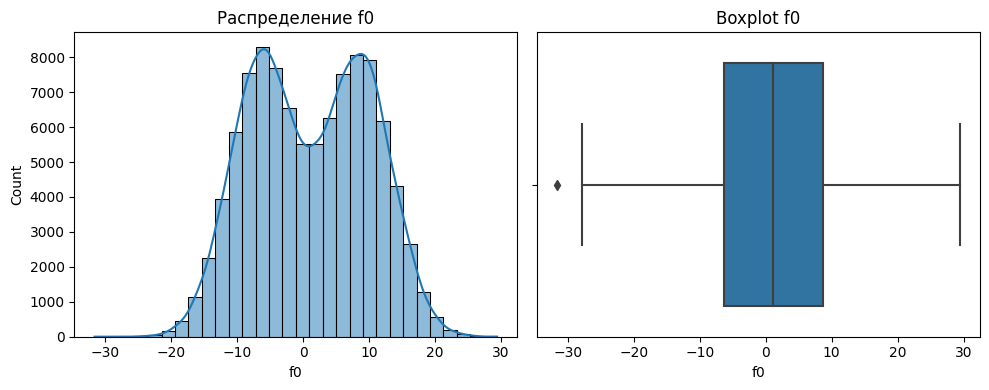

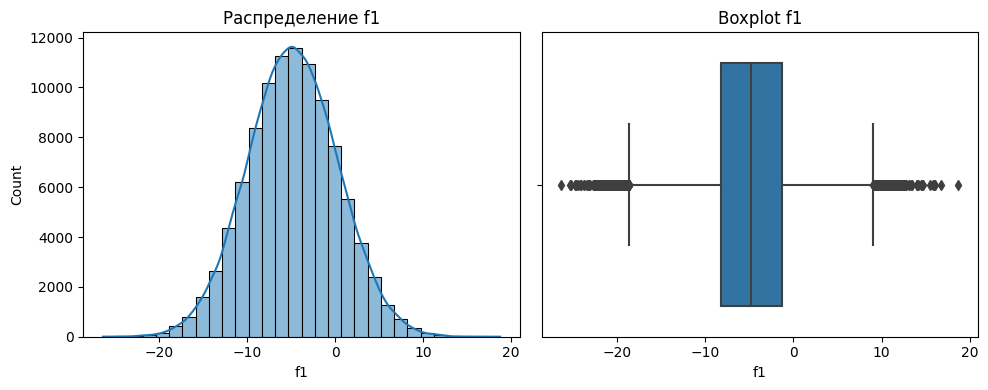

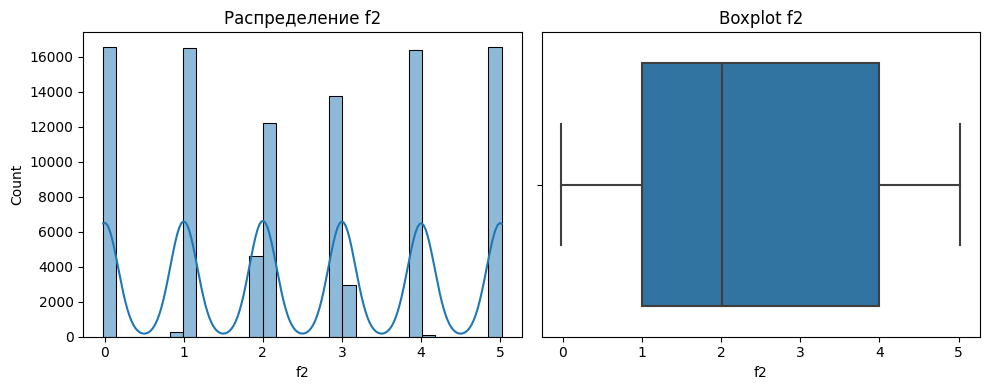

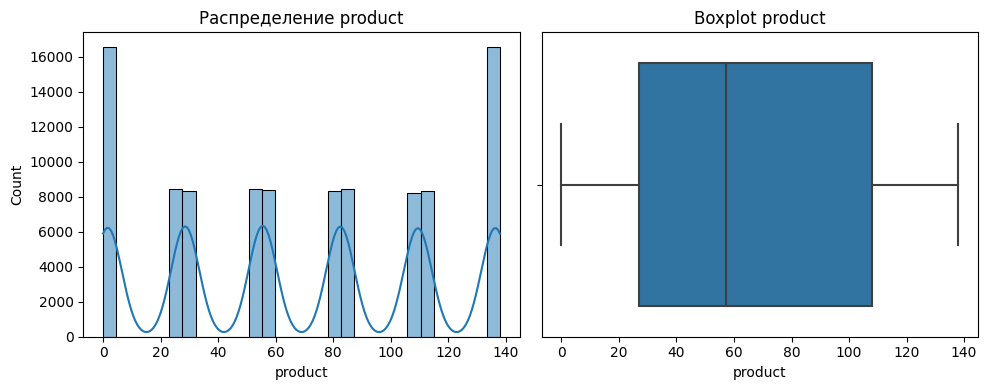

In [14]:
stat_analytics(df_geo_data_1)

### Итоги
Статистический анализ второго региона показал, что:
- product (целевая переменная) имеет мультимодальное распределение с шестью основными группами значений. Пики концентрации данных находятся примерно в точках 0, 30, 60, 90 и 110 и 130.
- f2 имеет мультимодальное распределение с пятью отчётливыми пиками, которые приходятся на целые числа: 0, 1, 2, 3 и 4.
- f0 имеет бимодальное распределение, что означает наличие двух отчётливых пиков. Один пик находится в районе -5, а другой — в районе +5
- f1 имеет симметричное нормальное распределение с пиком примерно около -5.

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838



Визуализация распределения количественных признаков


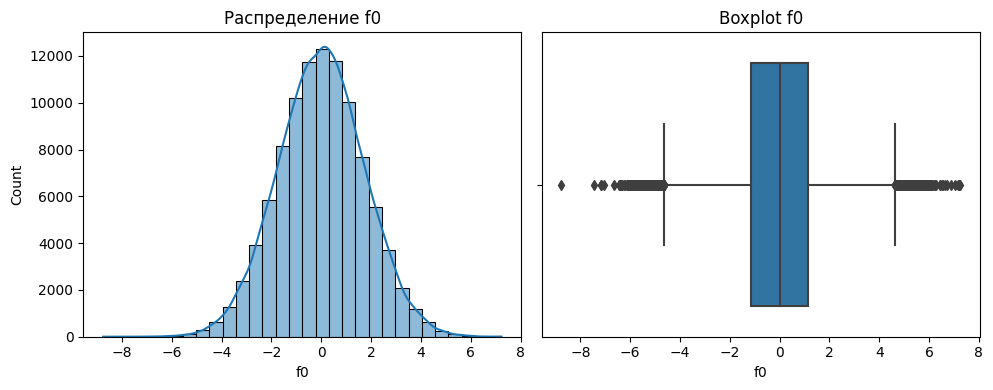

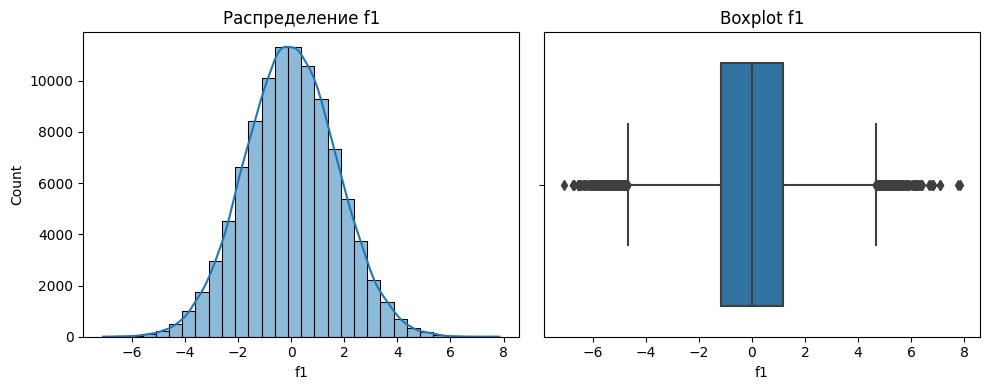

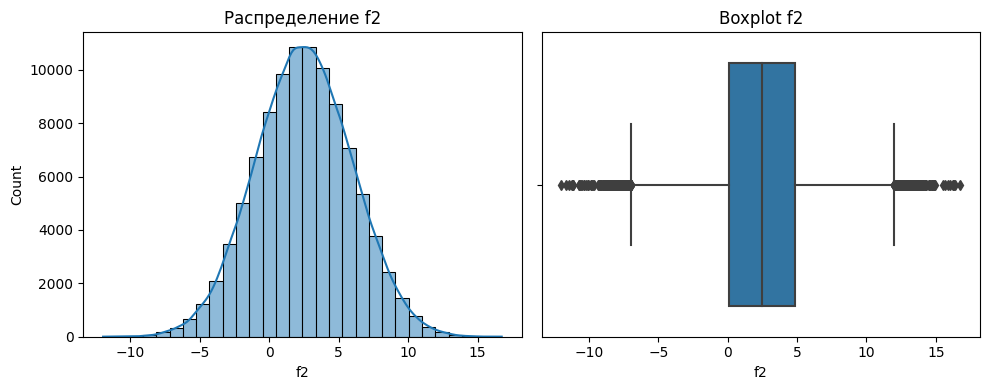

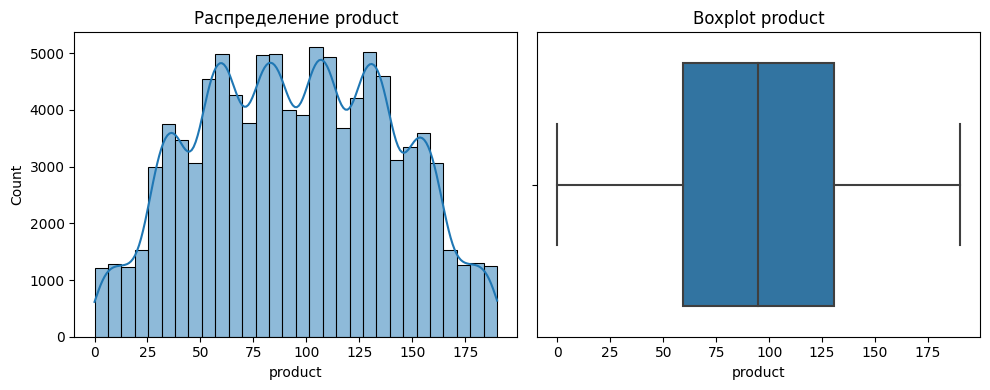

In [15]:
stat_analytics(df_geo_data_2)

### Итоги
Статистический анализ третьего региона показал, что:
- product (целевая переменная) имеет мультимодальное распределение с пятью основными группами значений. Пики концентрации данных находятся примерно в точках 30, 60, 75, 100, 125, 150 и 175.
- f2, f0 и f1 имеют нормальноек симметричной распределение, у всех наблюдаются выбросы.

# Корреляционный анализ

Проведём корреляционный анализ для визуализации корреляций признаков с целевым (product):

interval columns not set, guessing: ['f0', 'f1', 'f2', 'product']


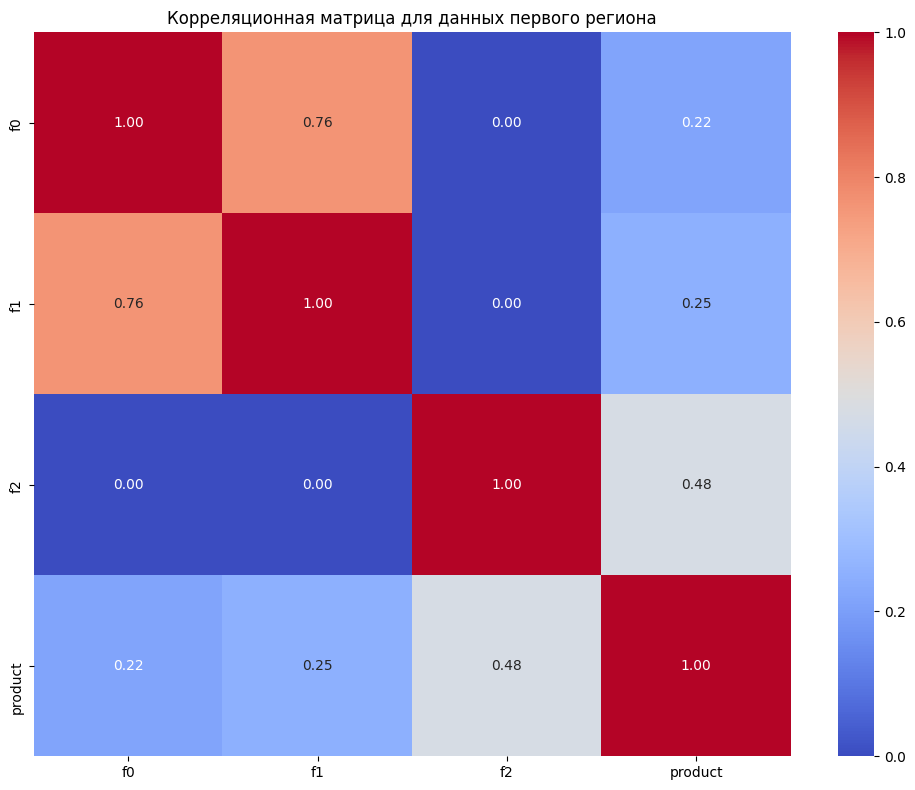

In [16]:
df_geo_data_0_ml = df_geo_data_0.set_index('id')
corr_matrix_0 = df_geo_data_0_ml.phik_matrix()
# визуализируем
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_0, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляционная матрица для данных первого региона")
plt.tight_layout();
plt.show();

Мультиколлинеарности не наблюдается, корреляция с целевой переменной у всех признаков хорошая 0.22 - 0.48.

interval columns not set, guessing: ['f0', 'f1', 'f2', 'product']


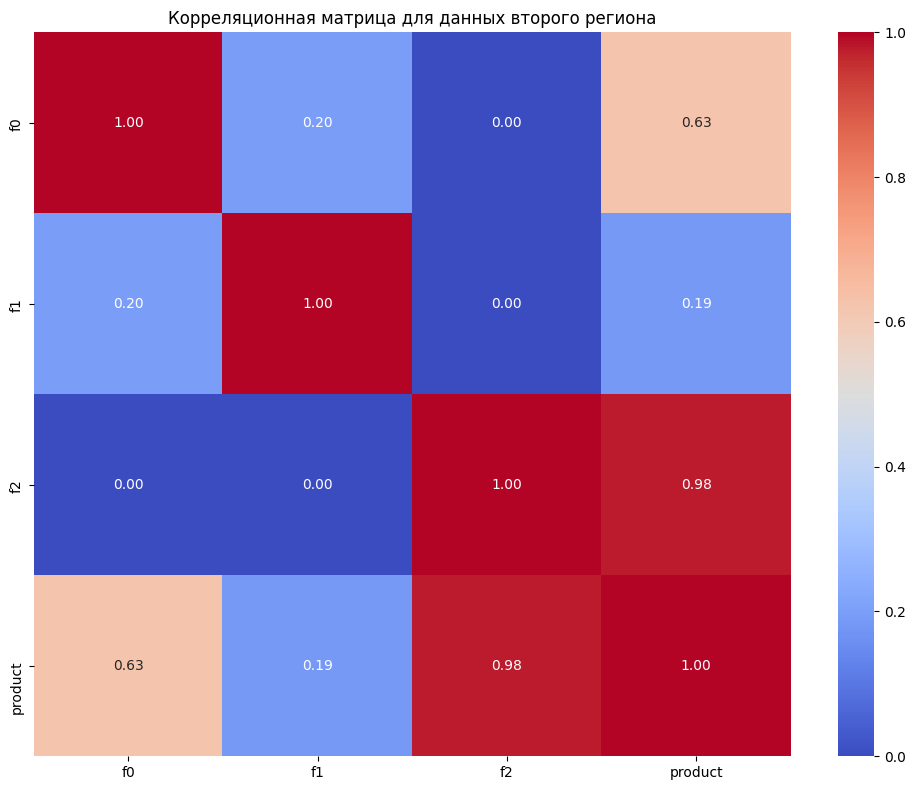

In [17]:
df_geo_data_1_ml = df_geo_data_1.set_index('id')
corr_matrix_1 = df_geo_data_1_ml.phik_matrix()
# визуализируем
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляционная матрица для данных второго региона")
plt.tight_layout();
plt.show();

Мультиколлинеарность отсутвует, наблюдается сильная корреляция целевого признака product и f2 (0.98), также хорошая корреляция целевого признака с f0 - 0.63.

interval columns not set, guessing: ['f0', 'f1', 'f2', 'product']


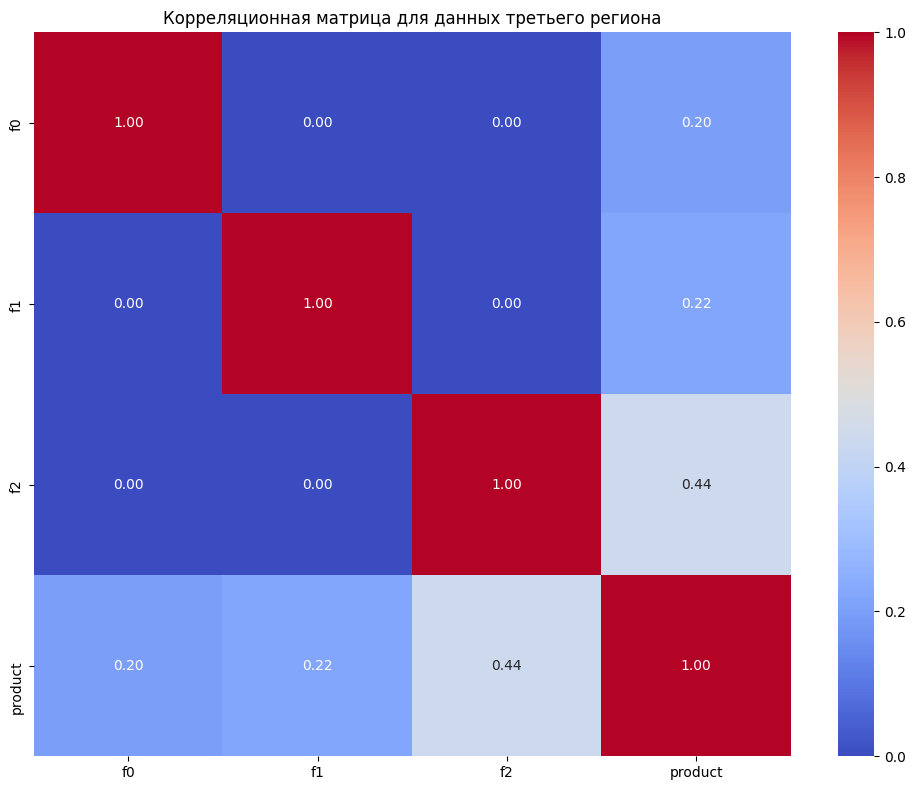

In [18]:
df_geo_data_2_ml = df_geo_data_2.set_index('id')
corr_matrix_2 = df_geo_data_2_ml.phik_matrix()
# визуализируем
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_2, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляционная матрица для данных третьего региона")
plt.tight_layout();
plt.show();

Мультиколлинеарность отсуствует, коллинеарность f0, f1, f2 - умеренная, 0.20 - 0.44.

# Обучение модели
Алгоритм действий:
- Разобьём данные на обучающую и валидационную выборки в соотношении 75:25;
- Обучим модель и сделаем предсказания на валидационной выборке;
- Сохраним предсказания и правильные ответы на валидационной выборке;
- Проанализируем результаты.


## Обучающая и валидационная выборка, обучение модели

Напишем функцию для разбиения датасета на обучающую и валидационную выборки, а также обучение модели:

In [19]:
def train_validate_model(data):
    features = data[['f0', 'f1', 'f2']]
    # выделяем целевой признак
    target = data['product']
    # разбиваем на выборки
    X_train, X_valid, y_train, y_valid = train_test_split(
        features, target, test_size=0.25, random_state=RANDOM_STATE)

    # инициализируем модель
    model = LinearRegression()
    model.fit(X_train, y_train) # обучаем модель
    predictions = model.predict(X_valid) # делаем предсказания
    
    rmse = np.sqrt(mean_squared_error(y_valid, predictions)) # оцениваем предсказания с помощью метрики RMSE 
    mean_pred = predictions.mean()
    
    return model, X_valid, y_valid.reset_index(drop=True), predictions, rmse, mean_pred

Применим функцию к данным:

In [20]:
regions = [df_geo_data_0, df_geo_data_1, df_geo_data_2]
models_info = []
full_results = []
for i, region in enumerate(regions):
    model, X_valid, y_valid, predictions, rmse, mean_pred = train_validate_model(region)
    print(f'\nРегион {i+1}:')
    print(f'  Средний предсказанный запас: {mean_pred:.2f} тыс. баррелей')
    print(f'  RMSE: {rmse:.2f}')
     # сохраняем всё нужное
    temp_df = pd.DataFrame({
        'region': i+1,
        'target': y_valid,
        'prediction': predictions
    })

    full_results.append(temp_df)

full_results_df = pd.concat(full_results, ignore_index=True)


Регион 1:
  Средний предсказанный запас: 92.40 тыс. баррелей
  RMSE: 37.76

Регион 2:
  Средний предсказанный запас: 68.71 тыс. баррелей
  RMSE: 0.89

Регион 3:
  Средний предсказанный запас: 94.77 тыс. баррелей
  RMSE: 40.15


### Вывод
Самое низкое значение RMSE на данных для 2 региона: 0.89. Но в то же время, модель для этого региона предсказывает куда меньший запас полезных ископаемых (68.71 тыс. баррелей), чем для 1 и 3 регионов, 92.40 и 94.77 тыс. баррелей соответственно.

# Подготовка к расчёту прибыли
Алгоритм действий:
- Рассчитаем достаточный объём сырья для безубыточной разработки новой скважины. Сравним полученный объём сырья со средним запасом в каждом регионе; 
- Сделаем выводы.

In [21]:
cost_per_well = BUDGET / SELECTED_WELLS / BARREL_INCOME  # порог безубыточности
print(f'\nМинимальный объём сырья для безубыточности: {cost_per_well:.2f} тыс. баррелей')


Минимальный объём сырья для безубыточности: 111.11 тыс. баррелей


### Вывод
Видим, что минимальный объём сырья для безубыточности (111.1) получился больше средних предсказанных запасов для 3х наших регионов. 

# Расчёт прибыли от 200 лучших скважин
Напишем функцию для расчёта прибыли от 200 лучших скважин:

In [24]:
def calculate_profit_v2(sample_df):
    
    top_200 = sample_df.sort_values(by='prediction', ascending=False).head(SELECTED_WELLS)
    total_product = top_200['target'].sum()
    
    # DEBUG: проверка формы
    if top_200.shape[0] != SELECTED_WELLS:
        print(f'Shape mismatch! You took {top_200.shape[0]} wells instead of {SELECTED_WELLS}')
    
    profit = total_product * BARREL_INCOME - BUDGET
    return profit

Рассчитаем прибыль от 200 лучших скважин в каждом регионе:

In [25]:
for region in full_results_df['region'].unique():
    region_data = full_results_df[full_results_df['region'] == region]
    profit = calculate_profit_v2(region_data[['target', 'prediction']])
    print(f"Регион {region}: прибыль от 200 лучших скважин: {profit:,.0f} руб.")

Регион 1: прибыль от 200 лучших скважин: 3,359,141,114 руб.
Регион 2: прибыль от 200 лучших скважин: 2,415,086,697 руб.
Регион 3: прибыль от 200 лучших скважин: 2,598,571,759 руб.


# Расчёт прибыли и рисков для каждого региона

- Применим технику Bootstrap с 1000 выборок, чтобы найти распределение прибыли;
- Найдём среднюю прибыль, 95%-й доверительный интервал и риск убытков. За убытки примем отрицательную прибыль;
- Напишем вывод: предложим регион для разработки скважин.

In [27]:
def bootstrap_v2(target, predictions):
    profits = []
    df = pd.DataFrame({'target': target, 'prediction': predictions})

    for _ in range(BOOTSTRAP_ITERATIONS):
        # случайная выборка из 500 скважин
        sample = df.sample(n=NUM_WELLS, replace=True)
        profit = calculate_profit_v2(sample)
        profits.append(profit)
    return profits

Сохраним результаты бутстрепа для всех регионов:

In [29]:
region_bootstrap_results = {}

for region in full_results_df['region'].unique():
    region_data = full_results_df[full_results_df['region'] == region]
    profits = bootstrap_v2(region_data['target'], region_data['prediction'])
    region_bootstrap_results[region] = pd.Series(profits)

Проведём анализ доверительных интервалов, риска убытков и средних:

In [31]:
region_stats = []

# Сбор статистики по регионам
for region, profits in region_bootstrap_results.items():
    mean_profit = profits.mean()
    lower = profits.quantile(0.025)
    upper = profits.quantile(0.975)
    loss_risk = (profits < 0).mean()

    region_stats.append({
        'region': region,
        'mean_profit': mean_profit,
        'loss_risk': loss_risk,
        'lower': lower,
        'upper': upper
    })

    print(f'Регион {region}:')
    print(f'  Средняя прибыль: {mean_profit:,.0f} руб.')
    print(f'  95% доверительный интервал: [{lower:,.2f}, {upper:,.2f}] руб.')
    print(f'  Риск убытков: {loss_risk:.2%}\n')

Регион 1:
  Средняя прибыль: 406,935,671 руб.
  95% доверительный интервал: [-126,850,502.27, 895,879,463.25] руб.
  Риск убытков: 7.40%

Регион 2:
  Средняя прибыль: 445,426,723 руб.
  95% доверительный интервал: [68,890,330.32, 845,847,106.15] руб.
  Риск убытков: 1.00%

Регион 3:
  Средняя прибыль: 381,271,854 руб.
  95% доверительный интервал: [-128,696,574.75, 892,117,451.39] руб.
  Риск убытков: 6.90%



Выберем лучший регион:

In [33]:
# Отбор регионов с допустимым риском
safe_regions = []

for r in region_stats:
    if r['loss_risk'] < LOSS_PROB_THRESHOLD:
        safe_regions.append(r)

if safe_regions:
    # Выбираем регион с максимальной прибылью среди безопасных
    best = max(safe_regions, key=lambda r: r['mean_profit'])
    print(f" Лучший регион для инвестиций: Регион {best['region']}")
    print(f"   Ожидаемая прибыль: {best['mean_profit']:,.0f} руб.")
    print(f"   Риск убытков: {best['loss_risk']:.2%}")
else:
    print("Нет регионов с допустимым уровнем риска.")

 Лучший регион для инвестиций: Регион 2
   Ожидаемая прибыль: 445,426,723 руб.
   Риск убытков: 1.00%


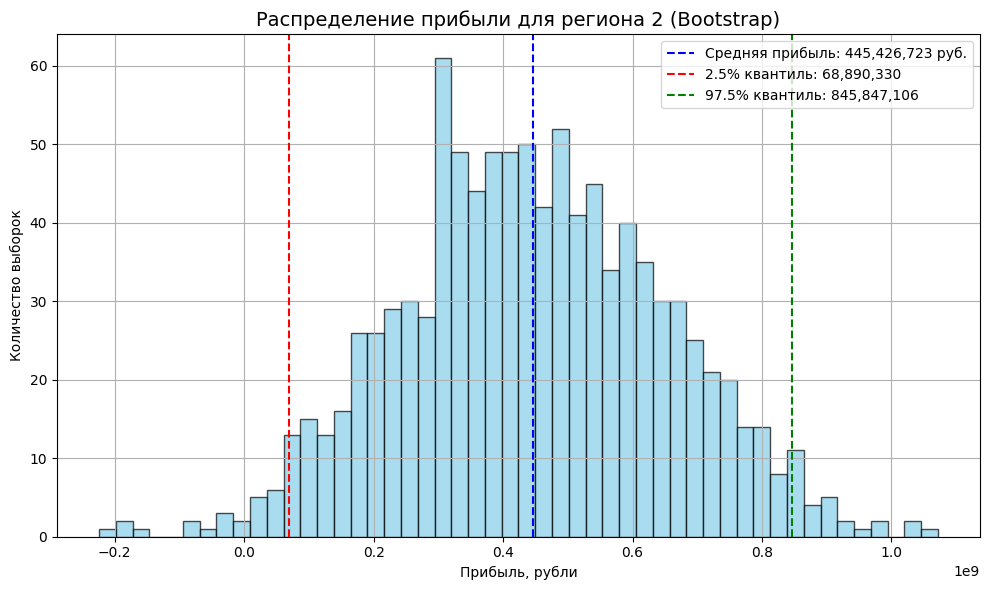

In [34]:
import matplotlib.pyplot as plt
import pandas as pd
best_region = best['region']
# Получаем прибыль для лучшего региона
best_profits = pd.Series(region_bootstrap_results[best_region])
mean_profit = best_profits.mean()
lower = best_profits.quantile(0.025)
upper = best_profits.quantile(0.975)

# Гистограмма
plt.figure(figsize=(10, 6))
plt.hist(best_profits, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(mean_profit, color='blue', linestyle='--', label=f'Средняя прибыль: {mean_profit:,.0f} руб.')
plt.axvline(lower, color='red', linestyle='--', label=f'2.5% квантиль: {lower:,.0f}')
plt.axvline(upper, color='green', linestyle='--', label=f'97.5% квантиль: {upper:,.0f}')

plt.title(f'Распределение прибыли для региона {best_region} (Bootstrap)', fontsize=14)
plt.xlabel('Прибыль, рубли')
plt.ylabel('Количество выборок')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show();

# Итоговый вывод
В ходе работы над проектом было выяснено, что:
- Регион 1:
  - Средний предсказанный запас: 92.40 тыс. баррелей
  - RMSE: 37.76

- Регион 2:
  - Средний предсказанный запас: 68.71 тыс. баррелей
  - RMSE: 0.89

- Регион 3:
  - Средний предсказанный запас: 94.77 тыс. баррелей
  - RMSE: 40.15

Модель для второго региона точнее всех предсказывает запасы нефти, но в то же время ожидаемые запасы самые малые. Плюсом к этому мы высчитали минимальный объём сырья для безубыточной добычи : 111.11 тыс. баррелей.

После этого были подсчитаны прибыли с 200 лучших скважин для каждого региона, результаты следующие:
Регион 1: прибыль от 200 лучших скважин: 3,359,141,114 руб.
Регион 2: прибыль от 200 лучших скважин: 2,415,086,697 руб.
Регион 3: прибыль от 200 лучших скважин: 2,598,571,759 руб.

Видим, что регион 1 может принести самую большую прибыль, регион 2 - самую меньшую, но и точность предсказаний для региона 2 самая высокая, соответственно - ближе к правде находятся данные со 2 региона.

Далее были подсчитаны риски убытков и прибыль, а так же доверительный интервал. Была использована техника bootstrap:

Регион 1:
  Средняя прибыль: 392,870,613 руб.
  95% доверительный интервал: [-155,904,330.29, 877,187,663.06] руб.
  Риск убытков: 8.00%

Регион 2:
  Средняя прибыль: 443,433,219 руб.
  95% доверительный интервал: [68,891,885.32, 817,333,147.64] руб.
  Риск убытков: 1.30%

Регион 3:
  Средняя прибыль: 382,587,923 руб.
  95% доверительный интервал: [-139,061,775.54, 919,254,830.15] руб.
  Риск убытков: 8.20%

И следом, аналитическим путём, был выбран самый перспективный регион для разработки по условиям бизнеса: риск убытков не должен превышать 2.5%, а также регион должен быть лидером по средней прибыли. 

На основании бизнес-требований, наша команда может предложить `Регион 2`.